# Marketing A/B Test Analysis

This notebook evaluates whether showing an advertisement (`ad`) increased user conversion compared with a public-service announcement (`psa`). The primary analysis is a two-sided, two-proportion z-test at $\alpha=0.05$.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_prep import load_data, summarize_groups
from src.power_analysis import analyze_power
from src.stats_tests import analyze_conversion

sns.set_theme(style='whitegrid', context='talk')
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load and validate the experiment

In [2]:
data = load_data(PROJECT_ROOT / 'data' / 'raw' / 'marketing_AB.csv')
group_summary = summarize_groups(data)
group_summary

,test_group,users,conversions,conversion_rate
0,ad,564577,14423,0.025547
1,psa,23524,420,0.017854


The loader enforces one row per user, both expected experiment groups, complete required fields, valid weekdays/hours, and non-negative ad counts.

In [3]:
quality_checks = pd.Series({
    'rows': len(data),
    'unique_users': data['user_id'].nunique(),
    'duplicate_users': int(data['user_id'].duplicated().sum()),
    'missing_values': int(data.isna().sum().sum()),
})
quality_checks

rows               588101
unique_users       588101
duplicate_users         0
missing_values          0
dtype: int64

## Primary conversion analysis

In [4]:
test_result = analyze_conversion(data)
pd.Series(test_result.to_dict())

treatment_group                    ad
control_group                     psa
treatment_users                564577
control_users                   23524
treatment_conversions           14423
control_conversions               420
treatment_rate               0.025547
control_rate                 0.017854
absolute_lift                0.007692
relative_lift                0.430851
confidence_level                 0.95
ci_lower                     0.005951
ci_upper                     0.009434
z_statistic                  7.370078
p_value                           0.0
statistically_significant        True
dtype: object

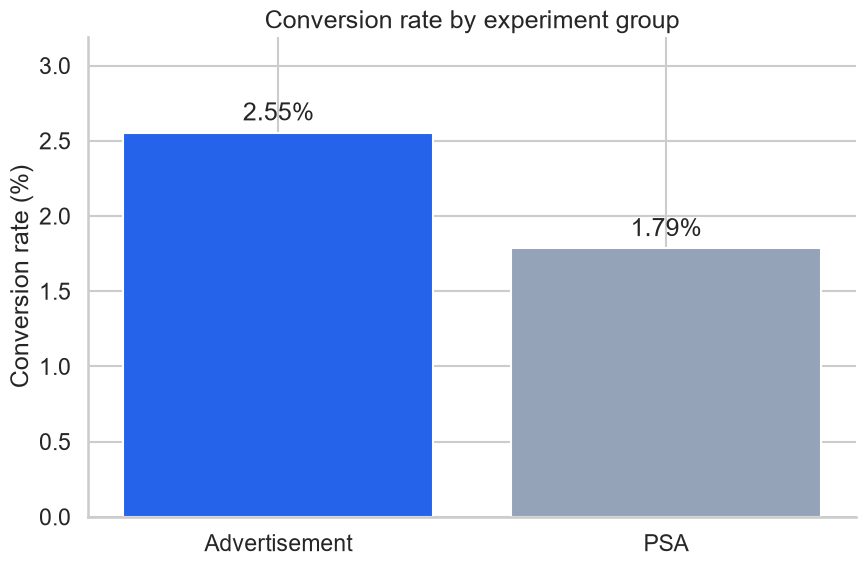

In [5]:
plot_data = group_summary.copy()
plot_data['label'] = plot_data['test_group'].map({'ad': 'Advertisement', 'psa': 'PSA'})
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(plot_data['label'], plot_data['conversion_rate'] * 100, color=['#2563eb', '#94a3b8'])
ax.set(title='Conversion rate by experiment group', ylabel='Conversion rate (%)', xlabel='')
ax.bar_label(bars, fmt='%.2f%%', padding=5)
ax.set_ylim(0, max(plot_data['conversion_rate'] * 100) * 1.25)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'conversion_rates.png', dpi=180, bbox_inches='tight')
plt.show()

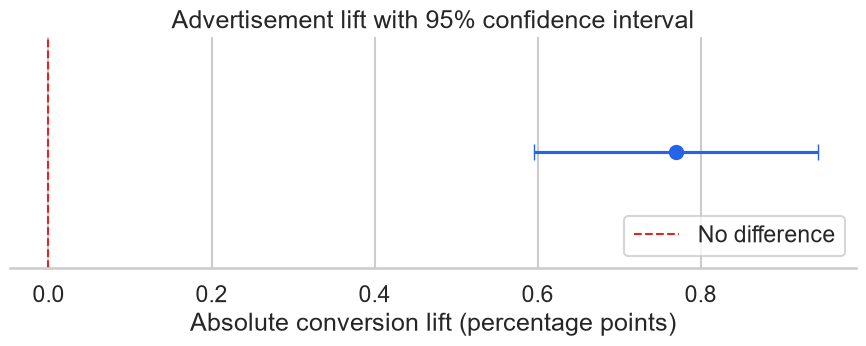

In [6]:
difference = test_result.absolute_lift * 100
lower = test_result.ci_lower * 100
upper = test_result.ci_upper * 100
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.errorbar(
    difference, 0,
    xerr=[[difference - lower], [upper - difference]],
    fmt='o', markersize=10, capsize=6, color='#2563eb'
)
ax.axvline(0, color='#dc2626', linestyle='--', linewidth=1.5, label='No difference')
ax.set(yticks=[], xlabel='Absolute conversion lift (percentage points)', title='Advertisement lift with 95% confidence interval')
ax.legend(loc='lower right')
sns.despine(ax=ax, left=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'conversion_lift_ci.png', dpi=180, bbox_inches='tight')
plt.show()

## Power and future sample-size planning

In [7]:
power_result = analyze_power(data, minimum_detectable_effect=0.002)
pd.Series(power_result.to_dict())

control_rate                      0.017854
observed_treatment_rate           0.025547
observed_absolute_lift            0.007692
control_users                 23524.000000
treatment_users              564577.000000
allocation_ratio                 24.000043
alpha                             0.050000
achieved_power                    1.000000
target_power                      0.800000
minimum_detectable_effect         0.002000
required_users_per_group      72547.000000
required_total_users         145094.000000
dtype: float64

The planning calculation uses a 0.20 percentage-point minimum detectable effect, 80% target power, 5% significance, and equal allocation. This is a statistical planning assumption; the business should replace it if a different minimum worthwhile effect is known.

## Exploratory timing analysis

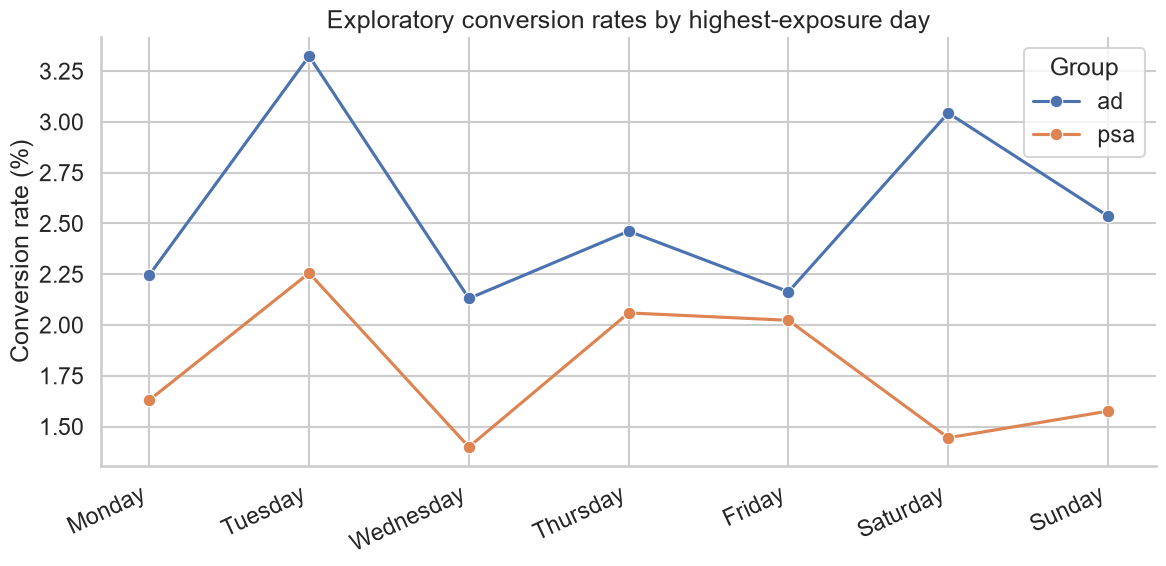

In [8]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = (data.groupby(['most_ads_day', 'test_group'])['converted'].mean().mul(100).rename('conversion_rate').reset_index())
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=daily, x='most_ads_day', y='conversion_rate', hue='test_group', hue_order=['ad', 'psa'], marker='o', sort=False, ax=ax)
ax.set(title='Exploratory conversion rates by highest-exposure day', xlabel='', ylabel='Conversion rate (%)')
ax.set_xticks(range(len(day_order)), day_order, rotation=25, ha='right')
ax.legend(title='Group')
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'conversion_by_day.png', dpi=180, bbox_inches='tight')
plt.show()

Day-level patterns are descriptive and were not used for the rollout decision. Multiple subgroup comparisons would require an explicit multiplicity strategy.

## Decision

The advertisement produced a statistically significant positive lift. The estimated increase is 0.769 percentage points (95% CI: 0.595 to 0.943), equivalent to a 43.1% relative improvement over PSA. Rollout is supported if the incremental value of this lift exceeds campaign delivery costs. See `reports/decision_memo.md` for qualifications and the final recommendation.